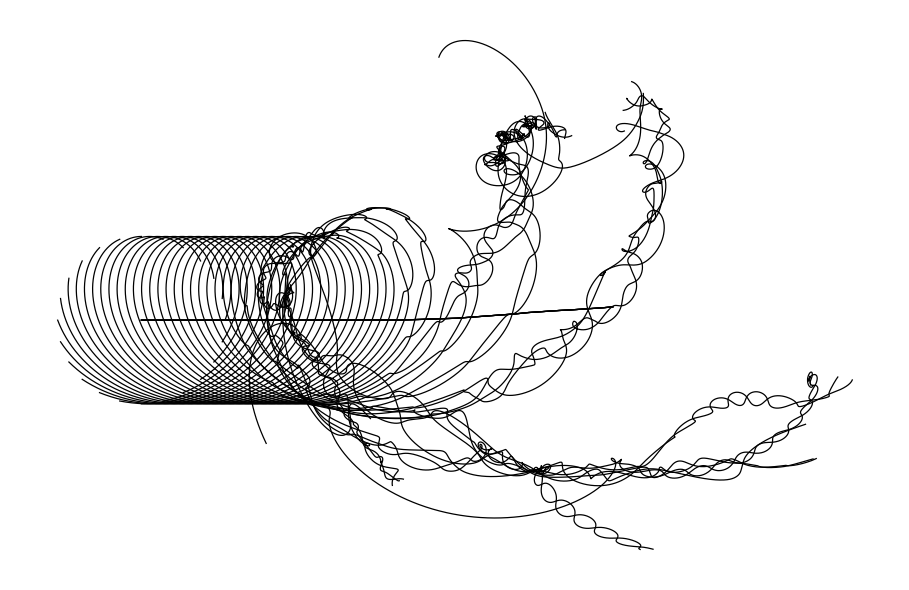

In [70]:
# N-body polygon drift art with escape detection, removal, and acceleration clamping
import numpy as np
import matplotlib.pyplot as plt

# ---------- parameters ----------
SEED = 7
np.random.seed(SEED)

G = 1.0
N_BODIES = 24           # 3 for triangle, any N >= 3
M_BASE = 1.0
MASS_PERTURB_INDEX = 0
MASS_PERTURB_FACTOR = 1.00

R = 7.0                 # initial circle radius
dt = 0.02
steps = 4_000

# force regularization
soft_eps = 5e-3         # Plummer softening (base)
R_MIN = 0.04            # never let pair distance fall below this (smoothly)
A_PAIR_MAX = 2.0        # max accel contribution from any single pair
A_MAX = 3.0             # max total accel magnitude per body

drift_speed = 0.5
linewidth = 0.9
fade_tail = False
figsize = (14, 6)
bg = "white"

# small jitters to seed breakup
pos_radius_jitter = 0.0
vel_scale_jitter = 0.0

# escape detection
ESCAPE_Z = 1000.0
ESCAPE_PERSIST = 300
MIN_RADIAL_SPEED = 0.02

# ---------- helpers ----------
def clamp_vecs(v, max_norm):
    """Scale rows of v so that ||row|| <= max_norm (continuous)."""
    n = np.linalg.norm(v, axis=1) + 1e-12
    s = np.minimum(1.0, max_norm / n)
    return v * s[:, None]

def pairwise_acc_masked(p, m, active, G=1.0, eps=1e-3,
                        r_min=0.0, a_pair_max=None, a_total_max=None):
    """Acceleration only among active bodies with smooth clamping."""
    idx = np.where(active)[0]
    a_full = np.zeros_like(p)
    if len(idx) <= 1:
        return a_full

    P = p[idx]
    M = m[idx]
    A = np.zeros_like(P)

    rmin2 = r_min * r_min
    eps2 = eps * eps

    for ii in range(len(idx)):
        d = P - P[ii]                                   # (K,2)
        dist2 = np.sum(d * d, axis=1)
        dist2 = np.maximum(dist2, rmin2)
        dist2 = dist2 + eps2

        mask = np.ones(len(idx), dtype=bool); mask[ii] = False
        d_ij = d[mask]
        m_ij = M[mask]
        invr3 = dist2[mask] ** (-1.5)

        contrib = (G * m_ij)[:, None] * d_ij * invr3[:, None]

        if a_pair_max is not None:
            contrib = clamp_vecs(contrib, a_pair_max)

        acc_i = contrib.sum(axis=0)
        A[ii] = acc_i

    if a_total_max is not None:
        n = np.linalg.norm(A, axis=1) + 1e-12
        s = np.minimum(1.0, a_total_max / n)
        A = A * s[:, None]

    a_full[idx] = A
    return a_full

def initial_polygon_rotation_velocity(p, m_equal, G=1.0):
    """Tangential speeds so average centripetal matches radial gravity at t=0."""
    c = p.mean(axis=0)
    rel = p - c
    Rvals = np.linalg.norm(rel, axis=1)
    R0 = np.mean(Rvals)
    acc = pairwise_acc_masked(p, m_equal, np.ones(len(p), bool), G, eps=soft_eps,
                              r_min=R_MIN*0.0, a_pair_max=None, a_total_max=None)
    a_rad = []
    for i in range(p.shape[0]):
        rhat = rel[i] / (np.linalg.norm(rel[i]) + 1e-12)
        a_rad.append(-np.dot(acc[i], rhat))
    a_rad = max(np.mean(a_rad), 0.0)
    omega = np.sqrt(a_rad / (R0 + 1e-12))
    v = np.zeros_like(p)
    for i in range(p.shape[0]):
        rhat = rel[i] / (np.linalg.norm(rel[i]) + 1e-12)
        that = np.array([-rhat[1], rhat[0]])
        v[i] = omega * R0 * that
    return v

# ---------- initial state ----------
angles = np.linspace(0.0, 2*np.pi, N_BODIES, endpoint=False)
pos = np.stack([R*np.cos(angles), R*np.sin(angles)], axis=1)

masses = np.full(N_BODIES, M_BASE, float)
masses[MASS_PERTURB_INDEX] *= MASS_PERTURB_FACTOR

m_equal = np.full(N_BODIES, M_BASE, float)
vel = initial_polygon_rotation_velocity(pos, m_equal, G)

# gentle jitters
pos *= (1.0 + pos_radius_jitter * np.sin(angles))[:, None]
vel *= (1.0 + np.linspace(-vel_scale_jitter, vel_scale_jitter, N_BODIES))[:, None]

# state
p = pos.copy()
v = vel.copy()
active = np.ones(N_BODIES, dtype=bool)
escape_counter = np.zeros(N_BODIES, dtype=int)
ended_at = np.full(N_BODIES, steps, dtype=int)

# store trajectories, NaN after removal to break the line
traj = np.full((steps, N_BODIES, 2), np.nan, float)
# center of mass trajectory (of active bodies), with drift applied
com_traj = np.full((steps, 2), np.nan, float)

# ---------- integrate with escape removal ----------
for t in range(steps):
    drift = np.array([drift_speed * t * dt, 0.0])
    traj[t, active] = p[active] + drift

    # compute clamped acceleration
    a0 = pairwise_acc_masked(
        p, masses, active, G,
        eps=soft_eps, r_min=R_MIN,
        a_pair_max=A_PAIR_MAX, a_total_max=A_MAX
    )

    p_half = p.copy()
    v_new = v.copy()
    p_half[active] = p[active] + v[active]*dt + 0.5*a0[active]*(dt*dt)

    a1 = pairwise_acc_masked(
        p_half, masses, active, G,
        eps=soft_eps, r_min=R_MIN,
        a_pair_max=A_PAIR_MAX, a_total_max=A_MAX
    )

    v_new[active] = v[active] + 0.5*(a0[active] + a1[active])*dt

    # propose next state
    p_next = p_half
    v_next = v_new

    # center of mass of currently active bodies
    idx = np.where(active)[0]
    if len(idx) >= 1:
        m_act = masses[idx]
        com = (m_act[:, None] * p_next[idx]).sum(axis=0) / (m_act.sum() + 1e-12)
        com_traj[t] = com + drift

    # escape detection
    if len(idx) >= 2:
        m_act = masses[idx]
        com_tmp = (m_act[:, None] * p_next[idx]).sum(axis=0) / (m_act.sum() + 1e-12)
        rel = p_next - com_tmp
        r = np.linalg.norm(rel, axis=1)

        r_act = r[active]
        r_med = np.median(r_act)
        mad = np.median(np.abs(r_act - r_med)) + 1e-9

        rhat = np.zeros_like(rel)
        rhat[active] = rel[active] / (np.linalg.norm(rel[active], axis=1)[:, None] + 1e-12)
        v_rad = np.sum(v_next * rhat, axis=1)

        candidates = (r > r_med + ESCAPE_Z*mad) & (v_rad > MIN_RADIAL_SPEED) & active
        escape_counter[candidates] += 1
        escape_counter[~candidates & active] = 0

        to_remove = (escape_counter >= ESCAPE_PERSIST) & active
        if np.any(to_remove):
            ended_at[to_remove] = t + 1
            active[to_remove] = False

    p = p_next
    v = v_next

    if active.sum() <= 1:
        break

# ---------- plot ----------
plt.figure(figsize=figsize, facecolor=bg)
ax = plt.gca(); ax.set_facecolor(bg)

# subsample for plotting
T = traj[::2]
COM = com_traj[::2]

# plot planets in black
if fade_tail:
    alphas = np.linspace(0.05, 0.95, T.shape[0])
    for k in range(N_BODIES):
        t_end = min(ended_at[k] // 2, T.shape[0])
        if t_end <= 1:
            continue
        for i in range(t_end-1):
            if np.any(np.isnan(T[i:i+2, k, :])):
                continue
            x = T[i:i+2, k, 0]; y = T[i:i+2, k, 1]
            ax.plot(x, y, color="k", lw=linewidth, alpha=alphas[i])
else:
    for k in range(N_BODIES):
        t_end = min(ended_at[k] // 2, T.shape[0])
        if t_end <= 2:
            continue
        xy = T[:t_end, k, :]
        mask = ~np.isnan(xy[:, 0])
        ax.plot(xy[mask, 0], xy[mask, 1], color="k", lw=linewidth)

# bounds for jitter scaling
xmin = np.nanmin(T[:, :, 0]); xmax = np.nanmax(T[:, :, 0])
ymin = np.nanmin(T[:, :, 1]); ymax = np.nanmax(T[:, :, 1])
xspan = (xmax - xmin + 1e-9)
yspan = (ymax - ymin + 1e-9)
span = max(xspan, yspan)

# plot COM trajectory in black, 5 passes with tiny jitter for pen thickness
mask_com = ~np.isnan(COM[:, 0])
rng = np.random.default_rng(SEED + 12345)
jitter_std = 0.000 * span  # small spatial jitter for thicker pen stroke

for _ in range(5):
    jitter = rng.normal(scale=jitter_std, size=COM.shape)
    ax.plot(COM[mask_com, 0] + jitter[mask_com, 0],
            COM[mask_com, 1] + jitter[mask_com, 1],
            color="k", lw=linewidth)

ax.set_aspect("equal", adjustable="box")
ax.axis("off")

xpad = 0.06 * xspan
ypad = 0.06 * yspan
ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

plt.tight_layout()
plt.savefig("03_n_polygon_breakup_2.svg", bbox_inches="tight")
plt.show()


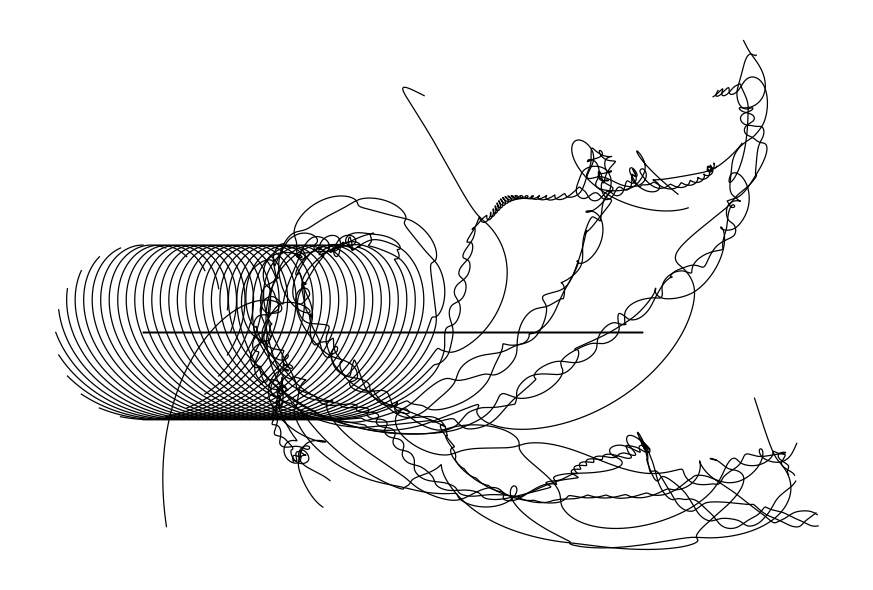

In [87]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- parameters ----------
SEED = 7
np.random.seed(SEED)

G = 1.0
N_BODIES = 24
M_BASE = 1.0
MASS_PERTURB_INDEX = 0
MASS_PERTURB_FACTOR = 1.00

R = 7.0
dt = 0.04
steps = 2_000

# force regularization
soft_eps = 5e-3
R_MIN = 0.5
A_PAIR_MAX = 1e10#2.0
A_MAX = 1e10#3.0

drift_speed = 0.5
linewidth = 0.9
fade_tail = False
figsize = (14, 6)
bg = "white"

# small jitters to seed breakup
pos_radius_jitter = 0.0
vel_scale_jitter = 0.0

# escape detection
ESCAPE_Z = 1000.0
ESCAPE_PERSIST = 300
MIN_RADIAL_SPEED = 0.02

# ---------- symmetry schedule ----------
# modes: "none", "all", "evenodd", "nth:k"
SYMMETRY_SCHEDULE = [
    #(0, "all"),
    #(800, "evenodd"),
    #(1600, "nth:3"),
]

# ---------- helpers ----------
def clamp_vecs(v, max_norm):
    n = np.linalg.norm(v, axis=1) + 1e-12
    s = np.minimum(1.0, max_norm / n)
    return v * s[:, None]

def pairwise_acc_masked(p, m, active, G=1.0, eps=1e-3,
                        r_min=0.0, a_pair_max=None, a_total_max=None):
    idx = np.where(active)[0]
    a_full = np.zeros_like(p)
    if len(idx) <= 1:
        return a_full

    P = p[idx]
    M = m[idx]
    A = np.zeros_like(P)

    rmin2 = r_min * r_min
    eps2 = eps * eps

    for ii in range(len(idx)):
        d = P - P[ii]
        dist2 = np.sum(d * d, axis=1)
        dist2 = np.maximum(dist2, rmin2) + eps2

        mask = np.ones(len(idx), dtype=bool); mask[ii] = False
        d_ij = d[mask]
        m_ij = M[mask]
        invr3 = dist2[mask] ** (-1.5)

        contrib = (G * m_ij)[:, None] * d_ij * invr3[:, None]
        if a_pair_max is not None:
            contrib = clamp_vecs(contrib, a_pair_max)
        A[ii] = contrib.sum(axis=0)

    if a_total_max is not None:
        n = np.linalg.norm(A, axis=1) + 1e-12
        s = np.minimum(1.0, a_total_max / n)
        A = A * s[:, None]

    a_full[idx] = A
    return a_full

def initial_polygon_rotation_velocity(p, m_equal, G=1.0):
    c = p.mean(axis=0)
    rel = p - c
    Rvals = np.linalg.norm(rel, axis=1)
    R0 = np.mean(Rvals)
    acc = pairwise_acc_masked(p, m_equal, np.ones(len(p), bool), G, eps=soft_eps,
                              r_min=0.0, a_pair_max=None, a_total_max=None)
    a_rad = []
    for i in range(p.shape[0]):
        rhat = rel[i] / (np.linalg.norm(rel[i]) + 1e-12)
        a_rad.append(-np.dot(acc[i], rhat))
    a_rad = max(np.mean(a_rad), 0.0)
    omega = np.sqrt(a_rad / (R0 + 1e-12))
    v = np.zeros_like(p)
    for i in range(p.shape[0]):
        rhat = rel[i] / (np.linalg.norm(rel[i]) + 1e-12)
        that = np.array([-rhat[1], rhat[0]])
        v[i] = omega * R0 * that
    return v

def current_mode(t, schedule):
    mode = "none"
    for ts, m in schedule:
        if t >= ts:
            mode = m
        else:
            break
    return mode

def parse_groups(mode, indices):
    if mode == "none":
        return []
    if mode == "all":
        return [indices.copy()] if len(indices) >= 2 else []
    if mode == "evenodd":
        ev = indices[indices % 2 == 0]
        od = indices[indices % 2 == 1]
        groups = []
        if len(ev) >= 2: groups.append(ev)
        if len(od) >= 2: groups.append(od)
        return groups
    if mode.startswith("nth:"):
        try:
            k = int(mode.split(":")[1])
        except:
            return []
        if k < 2:
            return []
        groups = []
        for start in range(k):
            g = indices[start::k]
            if len(g) >= 2:
                groups.append(g)
        return groups
    return []

def angle_mean(a):
    return np.arctan2(np.mean(np.sin(a)), np.mean(np.cos(a)))

def symmetrize_group_inplace(p, v, m, group_idx):
    """Symmetrise positions and velocities of a group in place."""
    if len(group_idx) < 2:
        return

    mg = m[group_idx]
    Pg = p[group_idx]
    Vg = v[group_idx]

    # weighted COM
    COM = (mg[:, None] * Pg).sum(axis=0) / (mg.sum() + 1e-12)

    # complex forms
    rel = Pg - COM
    z = rel[:, 0] + 1j * rel[:, 1]
    vc = Vg[:, 0] + 1j * Vg[:, 1]

    # order by current polar angle
    theta = np.angle(z)
    order = np.argsort(theta)
    z = z[order]
    vc = vc[order]
    ids_sorted = group_idx[order]

    K = len(z)
    phis = 2.0 * np.pi * np.arange(K) / K

    # estimate alpha from position phases against ideal phis
    theta_sorted = np.angle(z)
    delta = theta_sorted - phis
    delta = (delta + np.pi) % (2.0 * np.pi) - np.pi
    alpha = angle_mean(delta)

    # align both position and velocity by removing alpha
    z_aligned = z * np.exp(-1j * alpha)
    vc_aligned = vc * np.exp(-1j * alpha)

    # position template: mean vector gives radius and beta
    mean_vec = np.mean(z_aligned)
    r = np.abs(mean_vec)
    beta = np.angle(mean_vec)

    # perfect n-gon positions in aligned frame
    z_template = r * np.exp(1j * (phis + beta))

    # velocity template:
    # bring each velocity to index 0 frame by removing its local phase (phis+beta),
    # average to get v0, then replicate with the same phases
    vc0 = vc_aligned * np.exp(-1j * (phis + beta))
    v0 = np.mean(vc0)
    vc_template = v0 * np.exp(1j * (phis + beta))

    # rotate back by +alpha and map to xy
    z_new = z_template * np.exp(1j * alpha)
    vc_new = vc_template * np.exp(1j * alpha)

    P_new_sorted = COM[None, :] + np.column_stack([np.real(z_new), np.imag(z_new)])
    V_new_sorted = np.column_stack([np.real(vc_new), np.imag(vc_new)])

    p[ids_sorted] = P_new_sorted
    v[ids_sorted] = V_new_sorted

# ---------- initial state ----------
angles = np.linspace(0.0, 2*np.pi, N_BODIES, endpoint=False)
pos = np.stack([R*np.cos(angles), R*np.sin(angles)], axis=1)

masses = np.full(N_BODIES, M_BASE, float)
masses[MASS_PERTURB_INDEX] *= MASS_PERTURB_FACTOR

m_equal = np.full(N_BODIES, M_BASE, float)
vel = initial_polygon_rotation_velocity(pos, m_equal, G)

# gentle jitters
pos *= (1.0 + pos_radius_jitter * np.sin(angles))[:, None]
vel *= (1.0 + np.linspace(-vel_scale_jitter, vel_scale_jitter, N_BODIES))[:, None]

# state
p = pos.copy()
v = vel.copy()
active = np.ones(N_BODIES, dtype=bool)
escape_counter = np.zeros(N_BODIES, dtype=int)
ended_at = np.full(N_BODIES, steps, dtype=int)

# store trajectories, NaN after removal
traj = np.full((steps, N_BODIES, 2), np.nan, float)
com_traj = np.full((steps, 2), np.nan, float)

# ---------- integrate with scheduled symmetry ----------
for t in range(steps):
    drift = np.array([drift_speed * t * dt, 0.0])
    traj[t, active] = p[active] + drift

    a0 = pairwise_acc_masked(
        p, masses, active, G,
        eps=soft_eps, r_min=R_MIN,
        a_pair_max=A_PAIR_MAX, a_total_max=A_MAX
    )

    p_half = p.copy()
    v_new = v.copy()
    p_half[active] = p[active] + v[active]*dt + 0.5*a0[active]*(dt*dt)

    a1 = pairwise_acc_masked(
        p_half, masses, active, G,
        eps=soft_eps, r_min=R_MIN,
        a_pair_max=A_PAIR_MAX, a_total_max=A_MAX
    )

    v_new[active] = v[active] + 0.5*(a0[active] + a1[active])*dt

    # proposed next state
    p_next = p_half
    v_next = v_new

    # scheduled symmetry on positions and velocities
    mode = current_mode(t, SYMMETRY_SCHEDULE)
    if mode != "none":
        idx_act = np.where(active)[0]
        for g in parse_groups(mode, idx_act):
            symmetrize_group_inplace(p_next, v_next, masses, g)

    # COM of active bodies
    idx = np.where(active)[0]
    if len(idx) >= 1:
        m_act = masses[idx]
        com = (m_act[:, None] * p_next[idx]).sum(axis=0) / (m_act.sum() + 1e-12)
        com_traj[t] = com + drift

    # escape detection
    if len(idx) >= 2:
        m_act = masses[idx]
        com_tmp = (m_act[:, None] * p_next[idx]).sum(axis=0) / (m_act.sum() + 1e-12)
        rel = p_next - com_tmp
        r = np.linalg.norm(rel, axis=1)

        r_act = r[active]
        r_med = np.median(r_act)
        mad = np.median(np.abs(r_act - r_med)) + 1e-9

        rhat = np.zeros_like(rel)
        rhat[active] = rel[active] / (np.linalg.norm(rel[active], axis=1)[:, None] + 1e-12)
        v_rad = np.sum(v_next * rhat, axis=1)

        candidates = (r > r_med + ESCAPE_Z*mad) & (v_rad > MIN_RADIAL_SPEED) & active
        escape_counter[candidates] += 1
        escape_counter[~candidates & active] = 0

        to_remove = (escape_counter >= ESCAPE_PERSIST) & active
        if np.any(to_remove):
            ended_at[to_remove] = t + 1
            active[to_remove] = False

    p = p_next
    v = v_next

    if active.sum() <= 1:
        break

# ---------- plot ----------
plt.figure(figsize=figsize, facecolor=bg)
ax = plt.gca(); ax.set_facecolor(bg)

T = traj[::2]
COM = com_traj[::2]

if fade_tail:
    alphas = np.linspace(0.05, 0.95, T.shape[0])
    for k in range(N_BODIES):
        t_end = min(ended_at[k] // 2, T.shape[0])
        if t_end <= 1:
            continue
        for i in range(t_end - 1):
            if np.any(np.isnan(T[i:i+2, k, :])): continue
            x = T[i:i+2, k, 0]; y = T[i:i+2, k, 1]
            ax.plot(x, y, color="k", lw=linewidth, alpha=alphas[i])
else:
    for k in range(N_BODIES):
        t_end = min(ended_at[k] // 2, T.shape[0])
        if t_end <= 2: continue
        xy = T[:t_end, k, :]
        mask = ~np.isnan(xy[:, 0])
        ax.plot(xy[mask, 0], xy[mask, 1], color="k", lw=linewidth)

mask_com = ~np.isnan(COM[:, 0])
rng = np.random.default_rng(SEED + 12345)
for _ in range(5):
    jitter = rng.normal(scale=0.0, size=COM.shape)
    ax.plot(COM[mask_com, 0] + jitter[mask_com, 0],
            COM[mask_com, 1] + jitter[mask_com, 1],
            color="k", lw=linewidth)

ax.set_aspect("equal", adjustable="box")
ax.axis("off")

xmin = np.nanmin(T[:, :, 0]); xmax = np.nanmax(T[:, :, 0])
ymin = np.nanmin(T[:, :, 1]); ymax = np.nanmax(T[:, :, 1])
xspan = (xmax - xmin + 1e-9); yspan = (ymax - ymin + 1e-9)
xpad = 0.06 * xspan; ypad = 0.06 * yspan
ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

plt.tight_layout()
plt.savefig("03_n_polygon_breakup_scheduled_vel.svg", bbox_inches="tight")
plt.show()


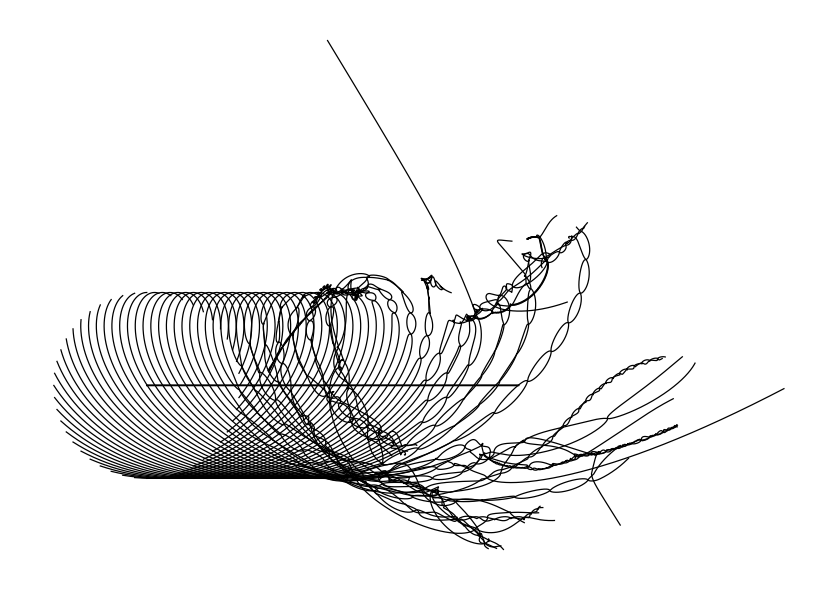

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- parameters ----------
SEED = 7
np.random.seed(SEED)

G = 1.0
N_BODIES = 48
M_BASE = 1.0
MASS_PERTURB_INDEX = 0
MASS_PERTURB_FACTOR = 1.00

R = 50.0
dt = 0.04
steps = 10_000

# force regularization
soft_eps = 5e-3
R_MIN = 0.5
A_PAIR_MAX = 1e10
A_MAX = 1e10

# plotting
drift_speed = 0.5
linewidth = 0.9
fade_tail = False
figsize = (14, 6)
bg = "white"

# jitters
pos_radius_jitter = 0.0
vel_scale_jitter = 0.0

# start speed controls
V_FACTOR = 1.00       # 1.0 circular, <1 inward drift, >1 outward
V_RADIAL = 0.0#-0.15      # extra radial fraction of circular speed (negative = inward)
V_NOISE = 0.0#0.02        # random velocity noise fraction of circular speed

# escape detection toggle
ESCAPE_ON = False
ESCAPE_Z = 1000.0
ESCAPE_PERSIST = 300
MIN_RADIAL_SPEED = 0.02

# ---------- helpers ----------
def clamp_vecs(v, max_norm):
    n = np.linalg.norm(v, axis=1) + 1e-12
    s = np.minimum(1.0, max_norm / n)
    return v * s[:, None]

def pairwise_acc_masked(p, m, active, G=1.0, eps=1e-3,
                        r_min=0.0, a_pair_max=None, a_total_max=None):
    idx = np.where(active)[0]
    a_full = np.zeros_like(p)
    if len(idx) <= 1:
        return a_full

    P = p[idx]
    M = m[idx]
    A = np.zeros_like(P)

    rmin2 = r_min * r_min
    eps2 = eps * eps

    for ii in range(len(idx)):
        d = P - P[ii]
        dist2 = np.sum(d * d, axis=1)
        dist2 = np.maximum(dist2, rmin2) + eps2

        mask = np.ones(len(idx), dtype=bool); mask[ii] = False
        d_ij = d[mask]
        m_ij = M[mask]
        invr3 = dist2[mask] ** (-1.5)

        contrib = (G * m_ij)[:, None] * d_ij * invr3[:, None]
        if a_pair_max is not None:
            contrib = clamp_vecs(contrib, a_pair_max)
        A[ii] = contrib.sum(axis=0)

    if a_total_max is not None:
        n = np.linalg.norm(A, axis=1) + 1e-12
        s = np.minimum(1.0, a_total_max / n)
        A = A * s[:, None]

    a_full[idx] = A
    return a_full

def initial_polygon_rotation_velocity(p, m_equal, G=1.0):
    """Return circular orbit tangential velocity field at t=0."""
    c = p.mean(axis=0)
    rel = p - c
    Rvals = np.linalg.norm(rel, axis=1)
    R0 = np.mean(Rvals)

    acc = pairwise_acc_masked(
        p, m_equal, np.ones(len(p), bool), G,
        eps=soft_eps, r_min=0.0, a_pair_max=None, a_total_max=None
    )
    # average inward acceleration magnitude on the mean ring
    a_rad = []
    for i in range(p.shape[0]):
        rhat = rel[i] / (np.linalg.norm(rel[i]) + 1e-12)
        a_rad.append(-np.dot(acc[i], rhat))
    a_rad = max(np.mean(a_rad), 0.0)

    omega = np.sqrt(a_rad / (R0 + 1e-12))
    speed_circ = omega * R0

    # unit tangents
    v = np.zeros_like(p)
    for i in range(p.shape[0]):
        rhat = rel[i] / (np.linalg.norm(rel[i]) + 1e-12)
        that = np.array([-rhat[1], rhat[0]])
        v[i] = speed_circ * that
    return v, speed_circ, (rel / (np.linalg.norm(rel, axis=1)[:, None] + 1e-12))

# ---------- initial state ----------
angles = np.linspace(0.0, 2*np.pi, N_BODIES, endpoint=False)
pos = np.stack([R*np.cos(angles), R*np.sin(angles)], axis=1)

masses = np.full(N_BODIES, M_BASE, float)
masses[MASS_PERTURB_INDEX] *= MASS_PERTURB_FACTOR
m_equal = np.full(N_BODIES, M_BASE, float)

# base circular velocity and helpers
v_circ, speed_circ, rhat_all = initial_polygon_rotation_velocity(pos, m_equal, G)

# scale and bias the initial velocity
rng0 = np.random.default_rng(SEED + 101)
vel = (
    V_FACTOR * v_circ
    + V_RADIAL * speed_circ * rhat_all
    + V_NOISE * speed_circ * rng0.normal(size=v_circ.shape)
)

# gentle jitters
pos *= (1.0 + pos_radius_jitter * np.sin(angles))[:, None]
vel *= (1.0 + np.linspace(-vel_scale_jitter, vel_scale_jitter, N_BODIES))[:, None]

# state
p = pos.copy()
v = vel.copy()
active = np.ones(N_BODIES, dtype=bool)
escape_counter = np.zeros(N_BODIES, dtype=int)
ended_at = np.full(N_BODIES, steps, dtype=int)

# storage
traj = np.full((steps, N_BODIES, 2), np.nan, float)
com_traj = np.full((steps, 2), np.nan, float)

# ---------- integrate ----------
for t in range(steps):
    drift = np.array([drift_speed * t * dt, 0.0])
    traj[t, active] = p[active] + drift

    a0 = pairwise_acc_masked(
        p, masses, active, G,
        eps=soft_eps, r_min=R_MIN,
        a_pair_max=A_PAIR_MAX, a_total_max=A_MAX
    )

    p_half = p.copy()
    v_new = v.copy()
    p_half[active] = p[active] + v[active]*dt + 0.5*a0[active]*(dt*dt)

    a1 = pairwise_acc_masked(
        p_half, masses, active, G,
        eps=soft_eps, r_min=R_MIN,
        a_pair_max=A_PAIR_MAX, a_total_max=A_MAX
    )

    v_new[active] = v[active] + 0.5*(a0[active] + a1[active])*dt

    p_next = p_half
    v_next = v_new

    # optional escape removal
    if ESCAPE_ON:
        idx = np.where(active)[0]
        if len(idx) >= 2:
            m_act = masses[idx]
            com_tmp = (m_act[:, None] * p_next[idx]).sum(axis=0) / (m_act.sum() + 1e-12)
            rel = p_next - com_tmp
            r = np.linalg.norm(rel, axis=1)

            r_act = r[active]
            r_med = np.median(r_act)
            mad = np.median(np.abs(r_act - r_med)) + 1e-9

            rhat = np.zeros_like(rel)
            rhat[active] = rel[active] / (np.linalg.norm(rel[active], axis=1)[:, None] + 1e-12)
            v_rad = np.sum(v_next * rhat, axis=1)

            candidates = (r > r_med + ESCAPE_Z*mad) & (v_rad > MIN_RADIAL_SPEED) & active
            escape_counter[candidates] += 1
            escape_counter[~candidates & active] = 0

            to_remove = (escape_counter >= ESCAPE_PERSIST) & active
            if np.any(to_remove):
                ended_at[to_remove] = t + 1
                active[to_remove] = False

    p = p_next
    v = v_next
    if active.sum() <= 1:
        break

    # COM track of active bodies
    idx = np.where(active)[0]
    m_act = masses[idx]
    com = (m_act[:, None] * p[idx]).sum(axis=0) / (m_act.sum() + 1e-12)
    com_traj[t] = com + drift

# ---------- plot ----------
plt.figure(figsize=figsize, facecolor=bg)
ax = plt.gca(); ax.set_facecolor(bg)

T = traj[::2]
COM = com_traj[::2]

if fade_tail:
    alphas = np.linspace(0.05, 0.95, T.shape[0])
    for k in range(N_BODIES):
        xy = T[:, k, :]
        mask = ~np.isnan(xy[:, 0])
        ii = np.where(mask)[0]
        for i in ii[:-1]:
            ax.plot(xy[i:i+2, 0], xy[i:i+2, 1], color="k", lw=linewidth, alpha=alphas[i])
else:
    for k in range(N_BODIES):
        t_end = T.shape[0] if ESCAPE_ON else T.shape[0]
        xy = T[:t_end, k, :]
        mask = ~np.isnan(xy[:, 0])
        ax.plot(xy[mask, 0], xy[mask, 1], color="k", lw=linewidth)

# COM thick stroke
mask_com = ~np.isnan(COM[:, 0])
rng = np.random.default_rng(SEED + 12345)
for _ in range(5):
    jitter = rng.normal(scale=0.0, size=COM.shape)
    ax.plot(COM[mask_com, 0] + jitter[mask_com, 0],
            COM[mask_com, 1] + jitter[mask_com, 1],
            color="k", lw=linewidth)

ax.set_aspect("equal", adjustable="box")
ax.axis("off")

xmin = np.nanmin(T[:, :, 0]); xmax = np.nanmax(T[:, :, 0])
ymin = np.nanmin(T[:, :, 1]); ymax = np.nanmax(T[:, :, 1])
xspan = (xmax - xmin + 1e-9); yspan = (ymax - ymin + 1e-9)
xpad = 0.06 * xspan; ypad = 0.06 * yspan
ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

plt.tight_layout()
plt.savefig("03_n_polygon_original_with_speed_control.svg", bbox_inches="tight")
plt.show()


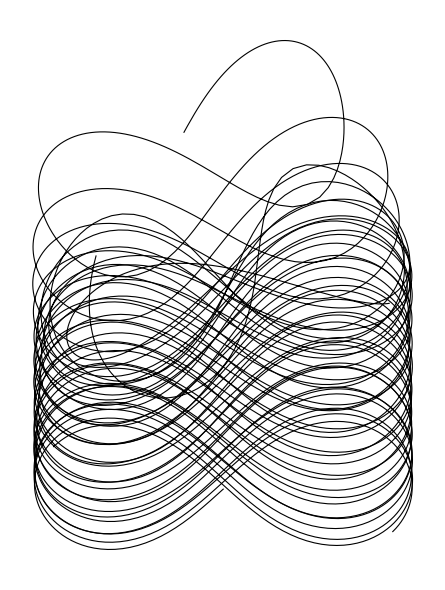

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# High level controls
# ==============================
PRESET = "figure8_3body"   # try: figure8_3body, lagrange3_perturbed, binary_intruder, ring_32_heavy_seed, ring_64
SEED = 7

# Physics
G = 1.0
soft_eps = 1e-3       # gravitational softening (avoids singularities)
DT = 0.02
STEPS =3700

# Plotting
figsize = (14, 6)
linewidth = 0.8
decimate = 2           # plot every Nth step to keep SVG light
bg = "white"
fade_tail = False

# Drift options to draw time as translation
# drift_vec gives a constant velocity of the whole drawing over the paper
# drift_mode = "plot"     only adds translation to what you draw (does not change dynamics)
# drift_mode = "dynamic"  adds the same velocity to all bodies each step (pure translation of state)
drift_vec = np.array([0.0, 0.02])   # units per unit time
drift_mode = "plot"                # "plot" or "dynamic"

rng = np.random.default_rng(SEED)


# ==============================
# Math helpers
# ==============================
def pairwise_acc(p, m, G=1.0, eps=1e-3):
    """
    Compute accelerations from gravity with Plummer softening.
    p: (N,2) positions, m: (N,) masses
    returns a: (N,2)
    """
    N = p.shape[0]
    a = np.zeros_like(p)
    for i in range(N):
        d = p - p[i]                       # vectors from i to j
        r2 = np.sum(d*d, axis=1) + eps*eps
        invr3 = r2**(-1.5)
        invr3[i] = 0.0
        a[i] = (G * (m * invr3)[:, None] * d).sum(axis=0)
    return a


def vel_verlet(p, v, m, dt, G=1.0, eps=1e-3):
    a0 = pairwise_acc(p, m, G, eps)
    p_half = p + v*dt + 0.5*a0*(dt*dt)
    a1 = pairwise_acc(p_half, m, G, eps)
    v_new = v + 0.5*(a0 + a1)*dt
    return p_half, v_new


# ==============================
# Presets
# ==============================
def init_figure8_3body():
    # Chenciner-Montgomery figure-eight initial conditions for equal masses, G=1
    m = np.array([1.0, 1.0, 1.0028], float)
    p = np.array([
        [-0.97000436,  0.24308753],
        [ 0.97000436, -0.24308753],
        [ 0.0       ,  0.0       ],
    ], float)
    v = np.array([
        [ 0.4662036850,  0.4323657300],
        [ 0.4662036850,  0.4323657300],
        [-0.93240737  , -0.86473146  ],
    ], float)
    # Small perturbation to seed chaos in long runs
    v += 1e-3 * rng.normal(size=v.shape)
    return p, v, m


def init_lagrange3_perturbed(R=5.0, w=0.6):
    # Three equal masses at an equilateral triangle with near rigid rotation, then perturb
    m = np.array([1.0, 1.0, 1.0], float)
    angles = np.array([0.0, 2*np.pi/3, 4*np.pi/3])
    p = np.stack([R*np.cos(angles), R*np.sin(angles)], axis=1)
    # choose angular velocity w, tangential velocity = w * R
    v = np.zeros_like(p)
    for i in range(3):
        rhat = p[i] / (np.linalg.norm(p[i]) + 1e-12)
        that = np.array([-rhat[1], rhat[0]])
        v[i] = w * R * that
    # small random kicks break perfect symmetry -> long term chaos
    p += 0.01 * rng.normal(size=p.shape)
    v += 0.01 * rng.normal(size=v.shape)
    return p, v, m


def init_binary_intruder():
    # Tight binary plus a lighter intruder that flies by
    m = np.array([2.0, 2.0, 0.2], float)
    a = 2.0  # binary separation scale
    p = np.array([
        [-a/2, 0.0],
        [ a/2, 0.0],
        [  0.0, 8.0],
    ], float)
    # circular velocities for the binary about their barycenter
    mu = m[0] + m[1]
    v_bin = np.sqrt(G*mu/(a)) * 0.5
    v = np.array([
        [ 0.0,  v_bin],
        [ 0.0, -v_bin],
        [ 0.5, -0.6],   # incoming intruder
    ], float)
    return p, v, m


def init_ring_N(n=32, R=50.0, heavy_index=0, heavy_factor=1.2, v_factor=1.01):
    # N equal masses on a ring with one heavier body and slightly off-circular speeds
    m = np.full(n, 1.0, float)
    m[heavy_index] *= heavy_factor
    ang = np.linspace(0.0, 2*np.pi, n, endpoint=False)
    p = np.stack([R*np.cos(ang), R*np.sin(ang)], axis=1)
    # estimate circular velocity from pairwise accelerations
    a = pairwise_acc(p, m, G, soft_eps)
    v = np.zeros_like(p)
    for i in range(n):
        r = p[i]
        Rn = np.linalg.norm(r) + 1e-12
        rhat = r / Rn
        that = np.array([-rhat[1], rhat[0]])
        a_rad = -np.dot(a[i], rhat)
        a_rad = max(a_rad, 0.0)
        speed = np.sqrt(a_rad * Rn)
        v[i] = v_factor * speed * that
    # tiny noise to break symmetry
    v += 0.002 * rng.normal(size=v.shape)
    return p, v, m


def init_ring_64():
    return init_ring_N(n=64, R=60.0, heavy_index=3, heavy_factor=1.5, v_factor=1.015)


def init_ring_32_heavy_seed():
    return init_ring_N(n=32, R=48.0, heavy_index=0, heavy_factor=1.3, v_factor=1.012)


PRESETS = {
    "figure8_3body": init_figure8_3body,
    "lagrange3_perturbed": init_lagrange3_perturbed,
    "binary_intruder": init_binary_intruder,
    "ring_32_heavy_seed": init_ring_32_heavy_seed,
    "ring_64": init_ring_64,
}


# ==============================
# Initialize
# ==============================
p, v, m = PRESETS[PRESET]()
N = len(m)

# center of mass to origin
com = (m[:, None] * p).sum(axis=0) / (m.sum() + 1e-12)
cov = (m[:, None] * v).sum(axis=0) / (m.sum() + 1e-12)
p -= com
v -= cov

# if drift_mode == dynamic, add same velocity to all bodies so the whole state translates
if drift_mode == "dynamic":
    v += drift_vec[None, :]


# ==============================
# Integrate and store trajectories
# ==============================
traj = np.empty((STEPS, N, 2), float); traj[:] = np.nan
for t in range(STEPS):
    # store current positions with optional plot-only drift
    if drift_mode == "plot":
        drift = drift_vec * (t * DT)
        traj[t] = p + drift[None, :]
    else:
        traj[t] = p

    # one VV step
    p, v = vel_verlet(p, v, m, DT, G, soft_eps)


# ==============================
# Plot
# ==============================
plt.figure(figsize=figsize, facecolor=bg)
ax = plt.gca(); ax.set_facecolor(bg)

T = traj[::decimate]
if fade_tail:
    alphas = np.linspace(0.05, 0.95, T.shape[0])
    for k in range(N):
        xy = T[:, k, :]
        mask = ~np.isnan(xy[:, 0])
        idx = np.where(mask)[0]
        for i in idx[:-1]:
            a = alphas[i]
            ax.plot(xy[i:i+2, 0], xy[i:i+2, 1], lw=linewidth, color="k", alpha=a)
else:
    for k in range(N):
        xy = T[:, k, :]
        mask = ~np.isnan(xy[:, 0])
        ax.plot(xy[mask, 0], xy[mask, 1], lw=linewidth, color="k")

ax.set_aspect("equal", adjustable="box")
ax.axis("off")

xmin = np.nanmin(T[:, :, 0]); xmax = np.nanmax(T[:, :, 0])
ymin = np.nanmin(T[:, :, 1]); ymax = np.nanmax(T[:, :, 1])
xspan = xmax - xmin + 1e-9; yspan = ymax - ymin + 1e-9
xpad = 0.06 * xspan; ypad = 0.06 * yspan
ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

plt.tight_layout()
plt.savefig(f"03_nbody_{PRESET}.svg", bbox_inches="tight")
plt.show()


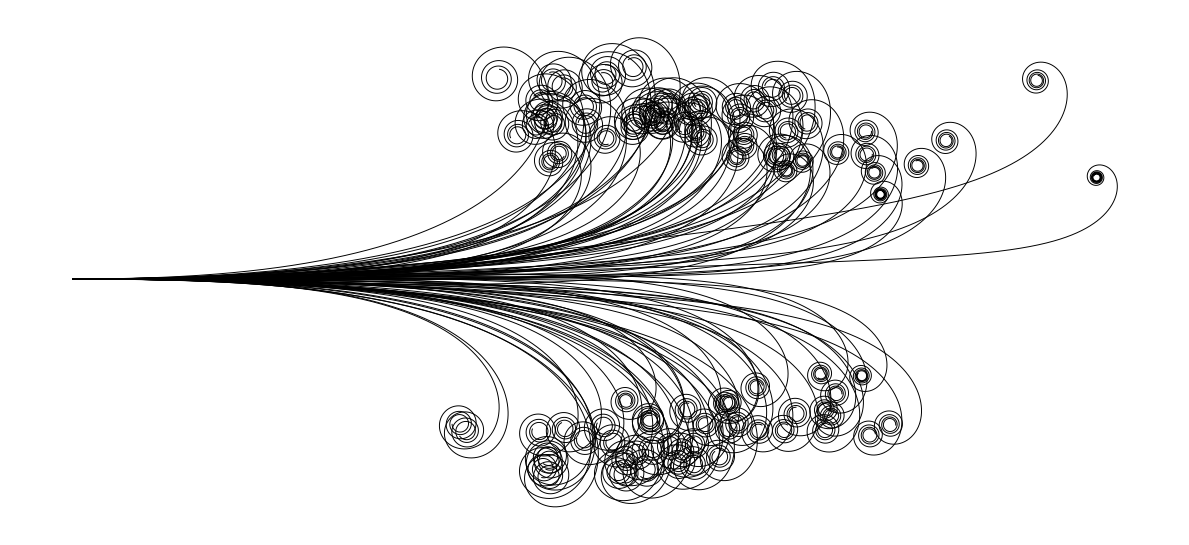

In [120]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Controls
# ==============================
SEED = 3
rng = np.random.default_rng(SEED)

N = 100                  # number of wheels
DT = 0.01
T = 100.0
STEPS = int(T / DT)

# Plot-only drift to encode time as translation (does not affect physics)
DRIFT_ON = False
DRIFT_VEC = np.array([0.0, 0.0])   # units per second

# Output
FIGSIZE = (12, 6)
LINEWIDTH = 0.7
BG = "white"
SAVE_PATH = "wheel_instability_falloff.svg"

# ==============================
# Physics model
# ==============================
# Speed decay (rolling + quadratic drag): dv/dt = -k1*v - k2*v^2
k1 = 0.08
k2 = 0.012

# Lean dynamics:
#   phi' = omega
#   omega' = (k_eff)*phi - c_phi*omega
# with k_eff = (b - a*v^2).
# Interpretation:
#   a*v^2 gives gyro + self-steer stabilizing with speed.
#   b is gravity driven toppling of an inverted pendulum.
#   When b - a*v^2 > 0 the lean is unstable and grows to a fall.
a = 0.040
b = 2.00
c_phi = 0.80

# Heading update from lean:
#   psi' = turn_gain(v) * tanh(phi)
# Use tanh to avoid blow-ups near fall, and a speed-based gain so
# turning rate grows as speed drops (tightening curves).
g = 9.81
v_floor = 0.00001
def turn_gain(v):
    return g / np.maximum(v, v_floor)

# Fall condition
phi_fall = np.deg2rad(48*180)   # fall when |lean| exceeds this
phi_clip = np.deg2rad(3000000)   # numerical guard

# ==============================
# Initial conditions
# ==============================
# Push speeds with mild spread
v = rng.normal(loc=8.0, scale=0.6, size=N)    # m/s

# Tiny initial lean and lean rate. Signs decide left vs right.
phi = rng.normal(loc=0.0, scale=np.deg2rad(1.0), size=N)
omega = rng.normal(loc=0.0, scale=np.deg2rad(2.0), size=N)

# Optionally bias a few to ensure both sides appear
flip_idx = rng.choice(N, size=N//8, replace=False)
phi[flip_idx] += np.sign(rng.normal(size=len(flip_idx))) * np.deg2rad(0.5)

# Headings and positions
psi = np.zeros(N)
x = np.zeros(N)
y = np.zeros(N)

# Active flags (stop when fallen)
active = np.ones(N, dtype=bool)

# Storage
traj = np.full((N, STEPS, 2), np.nan, float)

# ==============================
# Integrate
# ==============================
for t in range(STEPS):
    # store current positions with optional plot-only drift
    if DRIFT_ON:
        drift = DRIFT_VEC * (t * DT)
        traj[active, t, 0] = x[active] + drift[0]
        traj[active, t, 1] = y[active] + drift[1]
    else:
        traj[active, t, 0] = x[active]
        traj[active, t, 1] = y[active]

    if not np.any(active):
        break

    # speed decay
    dv = -(k1 * v + k2 * v * v) * DT
    v = np.maximum(0.0, v + dv)

    # lean dynamics
    k_eff = (b - a * v * v)   # positive -> unstable, negative -> self-stable
    domega = (k_eff * phi - c_phi * omega) * DT
    omega += domega
    phi += omega * DT
    phi = np.clip(phi, -phi_clip, phi_clip)

    # heading from lean
    psi += turn_gain(v) * np.tanh(phi) * DT

    # kinematics
    x += v * np.cos(psi) * DT
    y += v * np.sin(psi) * DT

    # check fall
    just_fell = active & (np.abs(phi) >= phi_fall)
    if np.any(just_fell):
        active[just_fell] = False
        # leave remaining traj as NaN so polylines terminate naturally

# ==============================
# Plot
# ==============================
plt.figure(figsize=FIGSIZE, facecolor=BG)
ax = plt.gca(); ax.set_facecolor(BG)

# Draw each trajectory as a single polyline. NaNs cut the stroke.
# Sort by final x for nicer overlap ordering.
end_x = np.nanmax(traj[:, :, 0], axis=1)
order = np.argsort(end_x)
for i in order:
    xy = traj[i]
    ax.plot(xy[:, 0], xy[:, 1], lw=LINEWIDTH, color="k")

ax.set_aspect("equal", adjustable="box")
ax.axis("off")

xmin = np.nanmin(traj[:, :, 0]); xmax = np.nanmax(traj[:, :, 0])
ymin = np.nanmin(traj[:, :, 1]); ymax = np.nanmax(traj[:, :, 1])
xpad = 0.06 * (xmax - xmin + 1e-9)
ypad = 0.06 * (ymax - ymin + 1e-9)
ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

plt.tight_layout()
plt.savefig(SAVE_PATH, bbox_inches="tight")
plt.show()


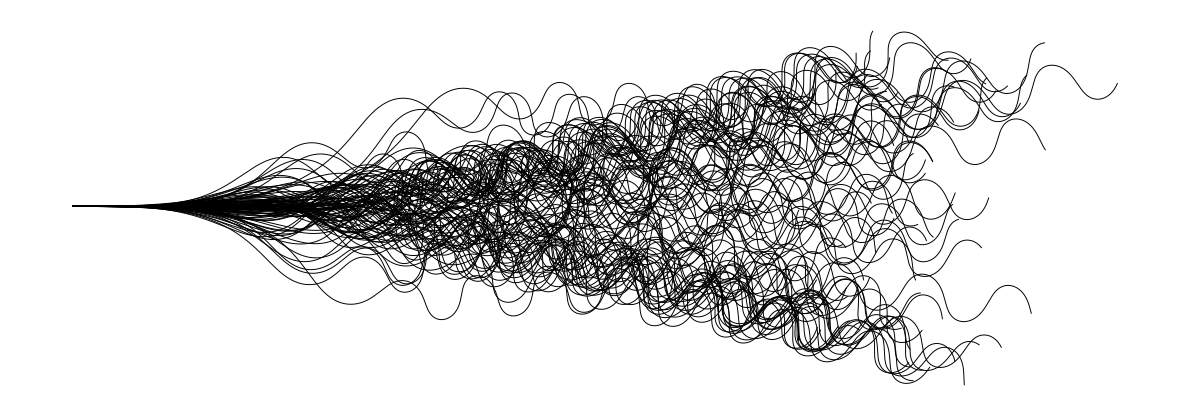

In [146]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Controls
# ==============================
SEED = 5
rng = np.random.default_rng(SEED)

N = 100
DT = 0.01
T = 30.0
STEPS = int(T / DT)

# Plot-only drift to encode time direction (no physics change)
DRIFT_ON = True
DRIFT_VEC = np.array([0.28, 0.0])   # units per second

# Output
FIGSIZE = (12, 6)
LINEWIDTH = 0.7
BG = "white"
SAVE_PATH = "wheel_bank_reset.svg"

# ==============================
# Physics
# ==============================
# Speed decay: dv/dt = -k1*v - k2*v^2
k1 = 0.001
k2 = 0.0005

# Base lean dynamics: phi' = omega; omega' = (b - a*v^2)*phi - c_phi*omega
# a*v^2 is gyro/self-steer stabilising with speed; b is gravity toppling
a = 0.045
b = 1.8
c_phi = 0.55

# Steer–lean coupling for banking reset
# Heading rate has countersteer proportional to lean rate
k_cs = 0.4           # countersteer gain (psi_dot term from omega)

# Align lean toward the lean that matches lateral accel
k_align = 6.0        # strength driving phi toward phi_eq

# Heading update
g = 9.81
v_floor = 0.8
def turn_gain(v):
    return g / np.maximum(v, v_floor)  # larger turning at lower speed

# Fall condition
phi_fall = np.deg2rad(89.0)   # terminate when |phi| exceeds this
phi_clip = np.deg2rad(88.0)   # numerical guard

# Tiny process noise to make paths diverge pleasantly
omega_noise = np.deg2rad(0.01)  # rad/sqrt(s)
psi_noise = 0.0                # keep headings clean; set small value for texture

# ==============================
# Initial conditions
# ==============================
v = rng.normal(loc=8.5, scale=0.7, size=N)

phi = rng.normal(loc=0.0, scale=np.deg2rad(0.1), size=N)
omega = rng.normal(loc=0.0, scale=np.deg2rad(0.2), size=N)

# slight bimodal bias so both sides appear
mask = rng.random(N) < 0.25
phi[mask] += np.deg2rad(0.6) * np.sign(rng.normal(size=mask.sum()))

psi = np.zeros(N)
x = np.zeros(N)
y = np.zeros(N)

active = np.ones(N, dtype=bool)
traj = np.full((N, STEPS, 2), np.nan, float)

# ==============================
# Integrate
# ==============================
for t in range(STEPS):
    # store current positions (with optional drift)
    if DRIFT_ON:
        drift = DRIFT_VEC * (t * DT)
        traj[active, t, 0] = x[active] + drift[0]
        traj[active, t, 1] = y[active] + drift[1]
    else:
        traj[active, t, 0] = x[active]
        traj[active, t, 1] = y[active]

    if not np.any(active):
        break

    # speed decay
    dv = -(k1 * v + k2 * v * v) * DT
    v = np.maximum(0.0, v + dv)

    # heading rate with countersteer
    psi_dot = turn_gain(v) * np.tanh(phi) + k_cs * omega
    if psi_noise > 0:
        psi_dot += psi_noise * rng.normal(size=N)

    # target lean for current lateral accel: tan(phi_eq) = (v*psi_dot)/g
    phi_eq = np.arctan(np.clip((v * psi_dot) / g, -5.0, 5.0))

    # lean dynamics with alignment toward phi_eq
    k_eff = (b - a * v * v)           # >0 unstable, <0 self-stable
    domega = (k_eff * phi - c_phi * omega + k_align * (phi_eq - phi)) * DT
    # small process noise to diversify trajectories
    domega += omega_noise * np.sqrt(DT) * rng.normal(size=N)

    omega += domega
    phi += omega * DT
    phi = np.clip(phi, -phi_clip, phi_clip)

    # integrate heading and position
    psi += psi_dot * DT
    x += v * np.cos(psi) * DT
    y += v * np.sin(psi) * DT

    # termination on fall
    just_fell = active & (np.abs(phi) >= phi_fall)
    active[just_fell] = False

# ==============================
# Plot
# ==============================
plt.figure(figsize=FIGSIZE, facecolor=BG)
ax = plt.gca(); ax.set_facecolor(BG)

# Order by final x for nicer overlap
end_x = np.nanmax(traj[:, :, 0], axis=1)
order = np.argsort(end_x)
for i in order:
    xy = traj[i]
    ax.plot(xy[:, 0], xy[:, 1], lw=LINEWIDTH, color="k")

ax.set_aspect("equal", adjustable="box")
ax.axis("off")

xmin = np.nanmin(traj[:, :, 0]); xmax = np.nanmax(traj[:, :, 0])
ymin = np.nanmin(traj[:, :, 1]); ymax = np.nanmax(traj[:, :, 1])
xpad = 0.06 * (xmax - xmin + 1e-9)
ypad = 0.06 * (ymax - ymin + 1e-9)
ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

plt.tight_layout()
plt.savefig(SAVE_PATH, bbox_inches="tight")
plt.show()


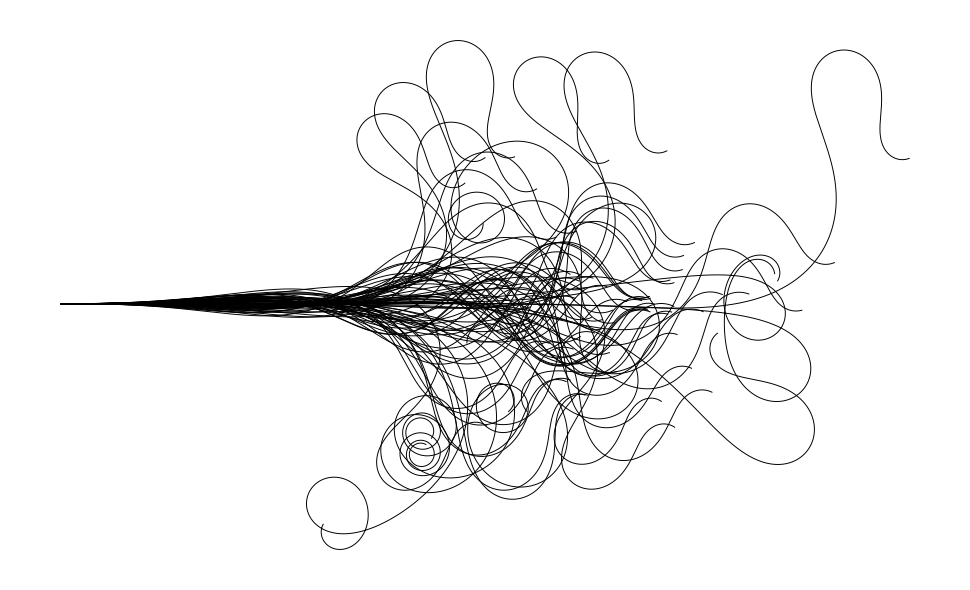

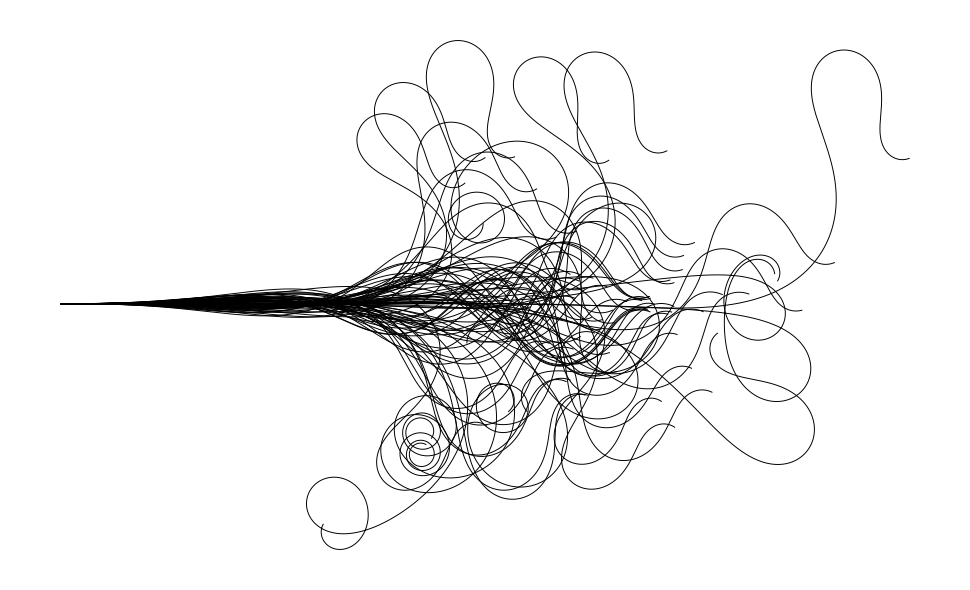

In [147]:
# Wheel banking-reset simulator with ipywidgets controls and SVG export
# Run this in a Jupyter/Colab notebook cell.

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import (
    FloatSlider, FloatLogSlider, IntSlider, Checkbox, Button, HBox, VBox,
    Layout, Label, BoundedFloatText, BoundedIntText
)
from IPython.display import display, clear_output
import math
import time
import random

# --------------------------
# Core simulation function
# --------------------------
def simulate(
    SEED=5, N=100, DT=0.01, T=30.0,
    DRIFT_ON=True, DRIFT_VX=0.28, DRIFT_VY=0.0,
    k1=1e-3, k2=5e-4,
    a=0.045, b=1.8, c_phi=0.55,
    k_cs=0.4, k_align=6.0,
    v0_mean=8.5, v0_std=0.7,
    phi0_std_deg=0.1, omega0_std_deg=0.2,
    phi_bias_frac=0.25, phi_bias_deg=0.6,
    g=9.81, v_floor=0.8,
    phi_fall_deg=89.0, phi_clip_deg=88.0,
    omega_noise_deg_sqrt_s=0.01, psi_noise=0.0,
    figsize=(12, 6), linewidth=0.7, bg="white"
):
    rng = np.random.default_rng(SEED)
    STEPS = int(T / DT)

    # Helper
    def turn_gain(v):
        return g / np.maximum(v, v_floor)

    # Initial conditions
    v = rng.normal(loc=v0_mean, scale=v0_std, size=N)
    phi = rng.normal(loc=0.0, scale=np.deg2rad(phi0_std_deg), size=N)
    omega = rng.normal(loc=0.0, scale=np.deg2rad(omega0_std_deg), size=N)

    if phi_bias_frac > 0.0:
        m = int(max(0, min(N, round(phi_bias_frac * N))))
        if m > 0:
            idx = rng.choice(N, size=m, replace=False)
            phi[idx] += np.deg2rad(phi_bias_deg) * np.sign(rng.normal(size=m))

    psi = np.zeros(N)
    x = np.zeros(N)
    y = np.zeros(N)

    active = np.ones(N, dtype=bool)
    traj = np.full((N, STEPS, 2), np.nan, float)

    phi_fall = np.deg2rad(phi_fall_deg)
    phi_clip = np.deg2rad(phi_clip_deg)
    omega_noise = np.deg2rad(omega_noise_deg_sqrt_s)

    # Integrate
    for t in range(STEPS):
        if DRIFT_ON:
            drift_x = DRIFT_VX * (t * DT)
            drift_y = DRIFT_VY * (t * DT)
            traj[active, t, 0] = x[active] + drift_x
            traj[active, t, 1] = y[active] + drift_y
        else:
            traj[active, t, 0] = x[active]
            traj[active, t, 1] = y[active]

        if not np.any(active):
            break

        # speed decay
        dv = -(k1 * v + k2 * v * v) * DT
        v = np.maximum(0.0, v + dv)

        # heading rate with countersteer
        psi_dot = turn_gain(v) * np.tanh(phi) + k_cs * omega
        if psi_noise > 0.0:
            psi_dot += psi_noise * rng.normal(size=N)

        # target lean for current lateral accel: tan(phi_eq) = (v*psi_dot)/g
        phi_eq = np.arctan(np.clip((v * psi_dot) / g, -5.0, 5.0))

        # lean dynamics with alignment toward phi_eq
        k_eff = (b - a * v * v)  # >0 unstable, <0 self-stable
        domega = (k_eff * phi - c_phi * omega + k_align * (phi_eq - phi)) * DT
        domega += omega_noise * math.sqrt(DT) * rng.normal(size=N)

        omega += domega
        phi += omega * DT
        phi = np.clip(phi, -phi_clip, phi_clip)

        # integrate heading and position
        psi += psi_dot * DT
        x += v * np.cos(psi) * DT
        y += v * np.sin(psi) * DT

        # termination on fall
        just_fell = active & (np.abs(phi) >= phi_fall)
        active[just_fell] = False

    # Plot
    fig = plt.figure(figsize=figsize, facecolor=bg)
    ax = plt.gca()
    ax.set_facecolor(bg)

    end_x = np.nanmax(traj[:, :, 0], axis=1)
    order = np.argsort(end_x)
    for i in order:
        xy = traj[i]
        ax.plot(xy[:, 0], xy[:, 1], lw=linewidth, color="k")

    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")

    xmin = np.nanmin(traj[:, :, 0]); xmax = np.nanmax(traj[:, :, 0])
    ymin = np.nanmin(traj[:, :, 1]); ymax = np.nanmax(traj[:, :, 1])
    xpad = 0.06 * (xmax - xmin + 1e-9)
    ypad = 0.06 * (ymax - ymin + 1e-9)
    ax.set_xlim(xmin - xpad, xmax + xpad)
    ax.set_ylim(ymin - ypad, ymax + ypad)

    plt.tight_layout()
    return fig, ax

# --------------------------
# Widgets
# --------------------------
w_seed = IntSlider(value=5, min=0, max=10_000, step=1, description="Seed", continuous_update=False)
w_N = IntSlider(value=100, min=10, max=500, step=10, description="N", continuous_update=False)
w_DT = FloatLogSlider(value=0.01, base=10, min=-3, max=-1, step=0.05, description="DT", continuous_update=False)
w_T = FloatSlider(value=30.0, min=5.0, max=120.0, step=1.0, description="T", continuous_update=False)

w_drift_on = Checkbox(value=True, description="Drift on")
w_drift_vx = FloatSlider(value=0.28, min=0.0, max=1.0, step=0.01, description="Drift vx", continuous_update=False)
w_drift_vy = FloatSlider(value=0.0, min=-1.0, max=1.0, step=0.01, description="Drift vy", continuous_update=False)

# Drag coefficients (log sliders)
w_k1 = FloatLogSlider(value=1e-3, base=10, min=-5, max=-1, step=0.05, description="k1", continuous_update=False)
w_k2 = FloatLogSlider(value=5e-4, base=10, min=-6, max=-1, step=0.05, description="k2", continuous_update=False)

# Lean dynamics
w_a = FloatSlider(value=0.045, min=0.0, max=0.2, step=0.001, description="a", continuous_update=False)
w_b = FloatSlider(value=1.8, min=0.0, max=4.0, step=0.01, description="b", continuous_update=False)
w_cphi = FloatSlider(value=0.55, min=0.0, max=2.0, step=0.01, description="c_phi", continuous_update=False)

# Banking reset couplings
w_kcs = FloatSlider(value=0.4, min=0.0, max=2.0, step=0.01, description="k_cs", continuous_update=False)
w_kalign = FloatLogSlider(value=6.0, base=10, min=-1, max=1.3, step=0.05, description="k_align", continuous_update=False)

# Initial condition spreads
w_v0 = FloatSlider(value=8.5, min=1.0, max=20.0, step=0.1, description="v0_mean", continuous_update=False)
w_v0s = FloatSlider(value=0.7, min=0.0, max=5.0, step=0.05, description="v0_std", continuous_update=False)
w_phi0 = FloatLogSlider(value=np.deg2rad(0.1), base=10, min=-4, max=-0.5, step=0.05, description="phi0_std(rad)", continuous_update=False)
w_om0 = FloatLogSlider(value=np.deg2rad(0.2), base=10, min=-4, max=0.0, step=0.05, description="omega0_std(rad)", continuous_update=False)

w_bias_frac = FloatSlider(value=0.25, min=0.0, max=1.0, step=0.01, description="phi_bias_frac", continuous_update=False)
w_bias_deg = FloatSlider(value=0.6, min=0.0, max=5.0, step=0.05, description="phi_bias_deg", continuous_update=False)

# Turn model
w_vfloor = FloatSlider(value=0.8, min=0.01, max=5.0, step=0.01, description="v_floor", continuous_update=False)

# Fall and clip angles
w_phi_fall = FloatSlider(value=89.0, min=5.0, max=89.9, step=0.1, description="phi_fall(deg)", continuous_update=False)
w_phi_clip = FloatSlider(value=88.0, min=5.0, max=89.9, step=0.1, description="phi_clip(deg)", continuous_update=False)

# Noise
w_om_noise = FloatLogSlider(value=np.deg2rad(0.01), base=10, min=-6, max=-0.5, step=0.05, description="omega_noise(rad/√s)", continuous_update=False)

# Aesthetics
w_lw = FloatSlider(value=0.7, min=0.1, max=2.0, step=0.05, description="Linewidth", continuous_update=False)
w_w = FloatSlider(value=12.0, min=4.0, max=20.0, step=0.5, description="Fig W", continuous_update=False)
w_h = FloatSlider(value=6.0, min=3.0, max=12.0, step=0.5, description="Fig H", continuous_update=False)

btn_run = Button(description="Run", button_style="")
btn_save = Button(description="Save SVG", button_style="success")

out = None
current_fig = {"fig": None, "ax": None}

def run_clicked(_):
    clear_output(wait=True)
    display(ui, btn_bar)
    fig, ax = simulate(
        SEED=w_seed.value,
        N=w_N.value,
        DT=w_DT.value,
        T=w_T.value,
        DRIFT_ON=w_drift_on.value,
        DRIFT_VX=w_drift_vx.value,
        DRIFT_VY=w_drift_vy.value,
        k1=w_k1.value,
        k2=w_k2.value,
        a=w_a.value,
        b=w_b.value,
        c_phi=w_cphi.value,
        k_cs=w_kcs.value,
        k_align=w_kalign.value,
        v0_mean=w_v0.value,
        v0_std=w_v0s.value,
        phi0_std_deg=np.rad2deg(w_phi0.value),
        omega0_std_deg=np.rad2deg(w_om0.value),
        phi_bias_frac=w_bias_frac.value,
        phi_bias_deg=w_bias_deg.value,
        v_floor=w_vfloor.value,
        phi_fall_deg=w_phi_fall.value,
        phi_clip_deg=w_phi_clip.value,
        omega_noise_deg_sqrt_s=np.rad2deg(w_om_noise.value),  # convert back to deg/sqrt(s)
        psi_noise=0.0,
        figsize=(w_w.value, w_h.value),
        linewidth=w_lw.value,
        bg="white"
    )
    current_fig["fig"] = fig
    current_fig["ax"] = ax
    display(fig)

def save_clicked(_):
    fig = current_fig["fig"]
    if fig is None:
        return
    rnd = random.randint(100000, 999999)
    fname = f"wheel_bank_reset_{rnd}.svg"
    fig.savefig(fname, bbox_inches="tight")
    print(f"Saved {fname}")

btn_run.on_click(run_clicked)
btn_save.on_click(save_clicked)

# Layout
row1 = HBox([w_seed, w_N, w_DT, w_T], layout=Layout(flex_flow="row wrap"))
row2 = HBox([w_drift_on, w_drift_vx, w_drift_vy], layout=Layout(flex_flow="row wrap"))
row3 = HBox([w_k1, w_k2, w_a, w_b, w_cphi], layout=Layout(flex_flow="row wrap"))
row4 = HBox([w_kcs, w_kalign, w_v0, w_v0s], layout=Layout(flex_flow="row wrap"))
row5 = HBox([w_phi0, w_om0, w_bias_frac, w_bias_deg], layout=Layout(flex_flow="row wrap"))
row6 = HBox([w_vfloor, w_phi_fall, w_phi_clip, w_om_noise], layout=Layout(flex_flow="row wrap"))
row7 = HBox([w_lw, w_w, w_h], layout=Layout(flex_flow="row wrap"))

ui = VBox([row1, row2, row3, row4, row5, row6, row7])
btn_bar = HBox([btn_run, btn_save], layout=Layout(justify_content="flex-start", gap="12px"))

display(ui, btn_bar)

# Auto-run once on load
run_clicked(None)
